 Colab Renderer Playground

This notebook mirrors `colab_renderer.py` with one function per cell so you can tweak settings safely without touching the main module.

In [5]:
import re
import importlib
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

try:
    nist_helper = importlib.import_module("nist_helper")
except Exception:
    try:
        # fallback for package-style import
        from . import nist_helper  # may fail if not package; wrapped in try above
    except Exception:
        nist_helper = None

In [6]:
def parse_nist_intensity(raw_value):
    """
    Parse a NIST intensity cell that may include descriptor characters.

    Returns:
        (numeric_value_or_nan, descriptor_string)
    """
    if pd.isna(raw_value):
        return (np.nan, "")
    s = str(raw_value).strip()
    m = re.search(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s)
    if not m:
        return (np.nan, s)
    try:
        num = float(m.group(0))
    except Exception:
        num = np.nan
    before = s[:m.start()].strip()
    after = s[m.end():].strip()
    descriptor = (before + " " + after).strip()
    descriptor = re.sub(r'[\s,]+', ' ', descriptor)
    return (num, descriptor)


In [7]:
def clean_nist_row(wavelength_str, rel_int_str):
    """
    Cleans NIST formatting flags like '*', 'bl', and spaces.
    Force-casts numeric types to string first to handle clean Excel data.
    Returns (float wavelength, float intensity) or (None, None) if invalid.
    """
    try:
        # Convert any raw floats/ints from Excel safely into text strings
        w_clean = str(wavelength_str).replace('*', '').replace('bl', '').strip()
        i_clean = str(rel_int_str).replace('*', '').replace('bl', '').replace('?', '').strip()
        
        # Check for empty cells or pandas NaN strings
        if not w_clean or w_clean.lower() == 'nan':
            return None, None
            
        # Extract numeric value for intensity
        # Handles cases where intensity might be a clean integer/float or a string like "9*"
        intensity = 0.0
        if i_clean and i_clean.lower() != 'nan':
            # Remove anything that isn't a digit or a decimal point
            i_numeric = ''.join(c for c in i_clean if c.isdigit() or c == '.')
            if i_numeric:
                intensity = float(i_numeric)
                
        return float(w_clean), intensity
    except ValueError:
        return None, None


In [8]:
def nist_descriptor_adjustments():
    """
    Intensity-only multipliers from the NIST descriptor reference.
    This is safe for your aesthetics because it does not change the renderer style,
    only the brightness input values.
    """
    return {
        '*': 1.0,
        ':': 1.0,
        '-': 0.8,
        'a': 0.5,
        'b': 1.0,
        'bl': 1.5,
        'B': 1.0,
        'c': 1.0,
        'd': 1.0,
        'D': 1.0,
        'E': 0.9,
        'f': 1.0,
        'g': 1.0,
        'G': 1.0,
        'H': 0.7,
        'h': 1.0,
        'hfs': 1.0,
        'i': 0.6,
        'j': 1.0,
        'l': 1.0,
        'm': 0.0,
        'p': 0.8,
        'q': 1.0,
        'r': 1.0,
        's': 1.0,
        't': 0.7,
        'u': 0.75,
        'w': 1.0,
        'x': 1.0,
    }

In [9]:
def resolve_column(df, candidates, label):
    """
    Find the first column whose name contains any keyword from the candidates.

    This is keyword-based matching, not exact phrase matching.
    Example:
    - candidate "relative intensity" matches headers containing
      "relative", "intensity", or both
    - candidate "wavelength_nm" matches headers containing "wavelength" or "nm"
    """
    headers = [(str(col).strip(), str(col).strip().lower()) for col in df.columns]

    # Build a flat keyword list from all candidates.
    # Each candidate may be a phrase; we split on non-alphanumeric characters.
    keywords = []
    for candidate in candidates:
        text = str(candidate).strip().lower()
        if not text:
            continue
        parts = [part for part in re.split(r'[^a-z0-9]+', text) if part]
        keywords.extend(parts if parts else [text])

    # Prefer exact matches first, then keyword containment.
    for original, normalized in headers:
        for candidate in candidates:
            candidate_norm = str(candidate).strip().lower()
            if candidate_norm and normalized == candidate_norm:
                return original

    for original, normalized in headers:
        for keyword in keywords:
            if keyword and keyword in normalized:
                return original

    raise KeyError(f"Could not find a {label} column. Available columns: {list(df.columns)}")

In [10]:
def nist_to_dataframe(df_raw, wavelength_candidates=None, intensity_candidates=None, apply_descriptor_adjustments=False):
    if wavelength_candidates is None:
        wavelength_candidates = ["Observed", "Observed Wavelength", "obs", "wavelength", "lambda", "wl", "wavelength_nm", "lambda_nm", "nm"]
    if intensity_candidates is None:
        intensity_candidates = ["Rel. Int.", "Relative Intensity", "Rel Int", "Relative", "Intensity", "A", "Aki", "gA", "gf", "weighted f", "f", "Intensity/Counts", "value"]

    wl_col = resolve_column(df_raw, wavelength_candidates, "wavelength")
    try:
        int_col = resolve_column(df_raw, intensity_candidates, "intensity")
    except KeyError:
        int_col = None

    out_rows = []
    if int_col is None:
        # no intensities -> unit intensity, unit width
        for _, row in df_raw.iterrows():
            out_rows.append({"nm": pd.to_numeric(row[wl_col], errors="coerce"), "Grey Val": 1.0, "Width_Mult": 1.0})
    else:
        parsed = df_raw[int_col].apply(parse_nist_intensity)
        for i, (_, row) in enumerate(df_raw.iterrows()):
            nm = pd.to_numeric(row[wl_col], errors="coerce")
            val, desc = parsed.iloc[i]
            if pd.isna(nm) or pd.isna(val):
                continue
            intensity_mult = 1.0
            width_mult = 1.0
            include = True
            if nist_helper is not None and desc:
                # token-match longest-first from helper if available
                keys = getattr(nist_helper, "_DESCRIPTOR_KEYS_SORTED", None)
                tokens = []
                if keys:
                    for k in keys:
                        if k and k in desc:
                            tokens.append(k)
                else:
                    # fallback: split descriptor into chars/words
                    tokens = [t for t in re.split(r'[\s,]+', desc) if t]
                eff = nist_helper.compute_descriptor_effects(tokens)
                include = eff.get("include", True)
                intensity_mult = eff.get("intensity_multiplier", 1.0)
                width_mult = eff.get("width_multiplier", 1.0)
            if not include:
                continue
            adj_val = val * intensity_mult if apply_descriptor_adjustments else val
            out_rows.append({"nm": nm, "Grey Val": adj_val, "Width_Mult": width_mult})

    out = pd.DataFrame(out_rows)
    if out.empty:
        return out

    out = out.dropna(subset=["nm", "Grey Val"]).sort_values("nm").reset_index(drop=True)

    vmin = out["Grey Val"].min()
    vmax = out["Grey Val"].max()
    if vmax - vmin == 0 or np.isnan(vmax - vmin):
        out["Grey Val"] = 1.0
    else:
        out["Grey Val"] = (out["Grey Val"] - vmin) / (vmax - vmin)

    # keep Width_Mult (default 1.0) for rendering width scaling
    if "Width_Mult" not in out.columns:
        out["Width_Mult"] = 1.0

    return out

In [11]:
def extract_and_sanitize_data(data_df, nm_col, intensity_col, x_min, x_max):
    """
    Cleans raw dataframe strings, extracts intensities, binds doublets/triplets
    by 4-decimal rounding, and normalizes them uniformly via exposure compression.
    """
    df_working = data_df.copy()
    
    # Format to uniform string matrix structures
    df_working['_clean_nm'] = df_working[nm_col].astype(str).str.replace('*', '', regex=False).str.replace('bl', '', regex=False).str.strip()
    df_working['_clean_int'] = df_working[intensity_col].astype(str).str.replace('*', '', regex=False).str.replace('bl', '', regex=False).str.replace('?', '', regex=False).str.strip()
    df_working['_clean_nm'] = pd.to_numeric(df_working['_clean_nm'], errors='coerce')

    # Parse and extract core numeric values
    def inline_extractor(val_str):
        if not val_str or val_str.lower() == 'nan': return 0.0
        nums = ''.join(c for c in str(val_str) if c.isdigit() or c == '.')
        return float(nums) if nums else 0.0

    df_working['_raw_intensity'] = df_working['_clean_int'].apply(inline_extractor)
    
    # Process visibility window bounds
    df_working = df_working.dropna(subset=['_clean_nm', '_raw_intensity']).copy()
    df_working = df_working[(df_working['_clean_nm'] >= x_min) & (df_working['_clean_nm'] <= x_max)].copy()
    
    # Group data by rounded wavelengths to aggregate intensity totals
    df_working['_rounded_nm'] = df_working['_clean_nm'].round(4)
    aggregated_df = df_working.groupby('_rounded_nm', as_index=False).agg({'_raw_intensity': 'sum'})
    aggregated_df = aggregated_df.sort_values(by='_rounded_nm').reset_index(drop=True)
    
    # Apply global non-linear scaling (exposure boost) to lift faint lines
    aggregated_df['_compressed_intensity'] = np.sqrt(aggregated_df['_raw_intensity'])
    min_val = aggregated_df['_compressed_intensity'].min()
    max_val = aggregated_df['_compressed_intensity'].max()
    val_range = max_val - min_val
    
    if val_range == 0 or np.isnan(val_range):
        aggregated_df['Normalized_Intensity'] = 1.0
    else:
        aggregated_df['Normalized_Intensity'] = (aggregated_df['_compressed_intensity'] - min_val) / val_range
        
    return aggregated_df

In [12]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    """
    Converts a wavelength in nanometers to an RGB color tuple (0-1 range).
    Based on code by Dan Bruton.
    """
    R, G, B = 0.0, 0.0, 0.0

    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = (1.0) ** gamma
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = (1.0) ** gamma
        B = ((-(wavelength - 510) / (510 - 490))) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = (1.0) ** gamma
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = (1.0) ** gamma
        G = ((-(wavelength - 645) / (645 - 580))) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0

    return (
        max(0.0, min(1.0, R)),
        max(0.0, min(1.0, G)),
        max(0.0, min(1.0, B)),
    )

In [13]:
def identify_spectral_peaks(aggregated_df, prominence_percentage, peak_wavelengths=None):
    """
    Identifies index positions of prominent emission peaks. 
    Uses rolling neighborhood max windows to preserve dense multiplets.
    """
    if peak_wavelengths is not None:
        nm_vals = aggregated_df['_rounded_nm'].values
        peaks = []
        for pw in peak_wavelengths:
            try: pv = float(pw)
            except Exception: continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        return sorted(set(peaks))
        
    peaks = []
    window_radius = 0  
    intensity_floor = aggregated_df['Normalized_Intensity'].max() * (prominence_percentage * 0.2)
    
    for i in range(window_radius, len(aggregated_df) - window_radius):
        current_int = aggregated_df.iloc[i]['Normalized_Intensity']
        if current_int < intensity_floor:
            continue
            
        neighborhood = aggregated_df.iloc[i - window_radius : i + window_radius + 1]['Normalized_Intensity']
        if current_int == neighborhood.max():
            peaks.append(i)
            
    return peaks

In [14]:
def render_spectrum_canvas(
    aggregated_df, 
    peaks, 
    x_min, 
    x_max, 
    fig_size, 
    mode, 
    min_brightness, 
    max_needle_y_scale, 
    min_needle_max_width_nm, 
    glow_width_multiplier, 
    glow_alpha, 
    peak_label_y_position, 
    dpi
    ):
    """
    Assembles the physical Matplotlib figure layout, plots uniform vector bars, 
    applies neon atmospheric aura glow, and prints text labels.
    """
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    text_color = 'white' if mode == 'dark' else 'black'

    fig.patch.set_facecolor('black' if mode == 'dark' else 'white')
    ax.set_facecolor('black')
    ax.yaxis.set_visible(False)
    ax.set_xlabel('Wavelength (nm)', color=text_color, fontweight='bold', labelpad=10)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)
    ax.grid(False)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1)

    for idx, row in aggregated_df.iterrows():
        nm_val = float(row['_rounded_nm'])
        norm_int = float(row['Normalized_Intensity'])
        base_rgb = np.array(wavelength_to_rgb(nm_val))
        is_peak = idx in peaks
        
        if is_peak:
            final_scale = min_brightness + (1 - min_brightness) * (norm_int ** 0.8)
            final_scale = min(1.0, final_scale * 1.4)
            z_order = 3
        else:
            final_scale = (min_brightness + (1 - min_brightness) * norm_int) * 0.4
            z_order = 1

        colored_rgb = base_rgb * final_scale
        y_height = max_needle_y_scale if is_peak else max_needle_y_scale * 0.7
        y_steps = np.array([0, y_height])
        
        widths = min_needle_max_width_nm * np.ones_like(y_steps)
        x_left = nm_val - widths / 2
        x_right = nm_val + widths / 2
        
        ax.fill_betweenx(y_steps, x_left, x_right, facecolor=colored_rgb, alpha=1.0 if is_peak else 0.3, edgecolor='none', zorder=z_order)

        if is_peak and glow_width_multiplier > 1.0:
            glow_widths = widths * glow_width_multiplier
            g_left = nm_val - glow_widths / 2
            g_right = nm_val + glow_widths / 2
            ax.fill_betweenx(y_steps, g_left, g_right, facecolor=colored_rgb, alpha=glow_alpha, edgecolor='none', zorder=2)

        if is_peak:
            ax.text(
                x=nm_val, y=peak_label_y_position, s=f"{nm_val:.1f}", 
                color=text_color, fontsize=8, rotation=60, 
                ha='left', va='bottom', zorder=4, rotation_mode='anchor'
            )

    plt.tight_layout()
    return fig, ax

In [15]:
def compute_label_positions(peak_nms, intensities=None, base_y=0.85, min_sep_nm=0.5, y_step=0.04, method="prefer_stronger_top", max_y=0.98):
    """
    Compute per-peak Y positions so labels for nearby peaks stack/stagger instead of overlapping.

    Args:
        peak_nms: list[float] - peak wavelengths (nm) in the same order you'll iterate peaks.
        intensities: optional list[float] - normalized intensities (same order), used by some methods.
        base_y: float - default label baseline (same as peak_label_y_position).
        min_sep_nm: float - minimum horizontal separation (nm) before labels considered "colliding".
        y_step: float - vertical step size to stack/stagger labels.
        method: "stack" | "stagger" | "prefer_stronger_top"
        max_y: float - clamp y so labels don't run off the top.

    Returns:
        list[float] - y position for each input peak (same order).
    """
    if not peak_nms:
        return []

    # prepare indices sorted by wavelength
    idx_sorted = sorted(range(len(peak_nms)), key=lambda i: peak_nms[i])
    result = [base_y] * len(peak_nms)

    # build clusters of peaks closer than min_sep_nm
    clusters = []
    cur = [idx_sorted[0]]
    for i in idx_sorted[1:]:
        if abs(peak_nms[i] - peak_nms[cur[-1]]) <= min_sep_nm:
            cur.append(i)
        else:
            clusters.append(cur)
            cur = [i]
    clusters.append(cur)

    for cluster in clusters:
        if len(cluster) == 1:
            result[cluster[0]] = base_y
            continue

        if method == "prefer_stronger_top" and intensities is not None:
            cluster_sorted = sorted(cluster, key=lambda k: -float(intensities[k]))
            n = len(cluster_sorted)
            if n == 1:
                result[cluster_sorted[0]] = base_y
            else:
                step = min(y_step, (max_y - base_y) / (n - 1))
                for pos, idx in enumerate(cluster_sorted):
                    result[idx] = base_y + pos * step

    return result

In [20]:
def plot_emission_spectrum(
    data_df,
    nm_col=None,
    intensity_col=None,
    prominence_percentage=0.12,
    x_min=400,
    x_max=750,
    fig_size=(15, 3),
    min_brightness=0.1,
    save_path=None,
    min_needle_max_width_nm=0.2,
    max_needle_max_width_nm=0.8,
    needle_shape_power=4,
    glow_width_multiplier=1.5,
    glow_alpha=0.25,
    dpi=600,
    mode='dark',
    show_grid=False,
    peak_label_y_position=0.9,
    max_needle_y_scale=0.8,
    peak_wavelengths=None,
    apply_descriptor_adjustments=False,
    show_peak_labels=True,
    label_min_normalized_intensity=0.20,
):
    # Resolve column names at runtime (accept many common aliases)
    if nm_col is None:
        nm_col = resolve_column(
            data_df,
            ["nm", "wavelength", "wavelength_nm", "lambda", "lambda_nm", "wl", "wl_nm"],
            "wavelength",
        )
    if intensity_col is None:
        intensity_col = resolve_column(
            data_df,
            [
                "Grey Val",
                "grey val",
                "gray val",
                "grayscale",
                "gray value",
                "intensity",
                "signal",
                "counts",
                "value",
                "int",
                "rel. int.",
                "grey",
            ],
            "intensity",
        )

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[nm_col] = pd.to_numeric(df_plot_data[nm_col], errors='coerce')

    # parse NIST-style cells
    parsed_intensity = df_plot_data[intensity_col].apply(parse_nist_intensity)
    df_plot_data['_raw_intensity'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[nm_col, '_raw_intensity']).copy()
    df_plot_data = df_plot_data[(df_plot_data[nm_col] >= x_min) & (df_plot_data[nm_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=nm_col).reset_index(drop=True)

    # Compute per-row descriptor effects if helper present
    if nist_helper is not None:
        def _effects_from_desc(desc):
            if not desc:
                return (1.0, 1.0, True)
            keys = getattr(nist_helper, "_DESCRIPTOR_KEYS_SORTED", None)
            tokens = []
            if keys:
                for k in keys:
                    if k and k in desc:
                        tokens.append(k)
            else:
                tokens = [t for t in re.split(r'[\s,]+', desc) if t]
            eff = nist_helper.compute_descriptor_effects(tokens)
            return (eff.get("intensity_multiplier", 1.0), eff.get("width_multiplier", 1.0), eff.get("include", True))

        effs = df_plot_data['_descriptor'].apply(lambda d: _effects_from_desc(d))
        df_plot_data['_intensity_mult'] = effs.apply(lambda x: x[0])
        df_plot_data['_width_mult'] = effs.apply(lambda x: x[1])
        df_plot_data['_include'] = effs.apply(lambda x: x[2])
        df_plot_data = df_plot_data[df_plot_data['_include']].copy()
    else:
        df_plot_data['_intensity_mult'] = 1.0
        df_plot_data['_width_mult'] = 1.0

    # Create adjusted intensity column used for normalization/detection
    if apply_descriptor_adjustments:
        df_plot_data['_adj_intensity'] = df_plot_data['_raw_intensity'] * df_plot_data['_intensity_mult']
    else:
        df_plot_data['_adj_intensity'] = df_plot_data['_raw_intensity']

    # Normalize using the adjusted intensity
    min_intensity_val = df_plot_data['_adj_intensity'].min()
    max_intensity_val = df_plot_data['_adj_intensity'].max()
    intensity_range = max_intensity_val - min_intensity_val
    if intensity_range == 0 or np.isnan(intensity_range):
        df_plot_data['Normalized_Intensity'] = 1.0
    else:
        df_plot_data['Normalized_Intensity'] = (df_plot_data['_adj_intensity'] - min_intensity_val) / intensity_range

    # Detection must always use raw numeric intensities; rendering uses adjusted values.
    detection_col = '_raw_intensity'
    intensity_col = '_adj_intensity'  # used for normalization/rendering
    
    # --- Peak Detection (raw data) ---
    if peak_wavelengths is not None:
        nm_vals = df_plot_data[nm_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        
        peaks = identify_spectral_peaks(
            df_plot_data.reset_index(drop=True),
            prominence_percentage=prominence_percentage,
            peak_wavelengths=peak_wavelengths,
        )

                # --- compute per-peak label Y positions to avoid overlap ---
        peak_nms = [float(df_plot_data.iloc[i][nm_col]) for i in peaks]
        peak_ints = [float(df_plot_data.iloc[i]['Normalized_Intensity']) for i in peaks]
        try:
            label_ys = compute_label_positions(
                peak_nms,
                intensities=peak_ints,
                base_y=peak_label_y_position,
                min_sep_nm=0.4,   # tune: nm distance considered "collision"
                y_step=0.08,     # tune: vertical step between stacked labels
                method="prefer_stronger_top",
                max_y=0.90,
            )
        except Exception:
            label_ys = [peak_label_y_position] * len(peaks)

    # Create the plot (use explicit Figure/Axis to avoid side-effects)
    fig, ax = plt.subplots(figsize=fig_size)

    # Set figure background and text colors based on mode
    if mode == 'dark':
        figure_bg_color = 'black'
        text_color = 'white'
        grid_color = 'darkgrey'
    else:  # light mode
        figure_bg_color = 'white'
        text_color = 'black'
        grid_color = 'lightgrey'

    fig.patch.set_facecolor(figure_bg_color)
    ax.set_facecolor('black')  # Always keep the spectrum plot area (axes) background black

    # Remove Y-axis completely as intensity is shown by brightness/color
    ax.yaxis.set_visible(False)

    # Set X-axis labels and color
    ax.set_xlabel('Wavelength (nm)', color=text_color)

    # Set major and minor tick locators
    major_locator = ticker.MultipleLocator(50)
    minor_locator = ticker.MultipleLocator(10)
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_minor_locator(minor_locator)

    # Set tick parameters for both major and minor ticks
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    # Set X-axis limits
    ax.set_xlim(x_min, x_max)

    # Set a fixed y-range for the vertical lines to appear as a bar
    ax.set_ylim(0, 1)
   
    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Normalized_Intensity', 0.0))
        _base_rgb = wavelength_to_rgb(_nm)
        _final_scale = min_brightness + (1 - min_brightness) * _ni
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = _nm - _bg_widths / 2
        _x_right = _nm + _bg_widths / 2
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=0.28, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_normalized_intensity = df_plot_data.iloc[peak_index]['Normalized_Intensity']

        # Get base RGB color for the peak wavelength
        base_rgb = wavelength_to_rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        _peak_emphasis = 1.4
        final_intensity_scale = min_brightness + (1 - min_brightness) * (peak_normalized_intensity ** _peak_gamma)
        final_intensity_scale = min(1.0, final_intensity_scale * _peak_emphasis)

        colored_rgb = (
            base_rgb[0] * final_intensity_scale,
            base_rgb[1] * final_intensity_scale,
            base_rgb[2] * final_intensity_scale,
        )

        # Scale the maximum width of the needle based on normalized intensity

        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_normalized_intensity
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)
        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost
        

        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (
            y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)
        )

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = peak_nm - glow_current_widths_nm / 2
        glow_x_right = peak_nm + glow_current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=colored_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = scaled_max_width_nm * width_profile_factor
        x_left = peak_nm - current_widths_nm / 2
        x_right = peak_nm + current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=colored_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
        should_label = show_peak_labels and peak_normalized_intensity >= label_min_normalized_intensity
        if should_label:
            ax.text(peak_nm, y_for_label, f"{peak_nm:.2f}", color="white", ha="left", va="bottom",
                    fontsize=6, rotation=60, rotation_mode="anchor", zorder=3,
                    path_effects=[pe.withStroke(linewidth=1.5, foreground="black")])

    plt.title(f'Traditional Emission Spectrum Visualization ({mode.capitalize()} Mode)', color=text_color, y=1.0, pad=10)

    if show_grid:
        ax.grid(True, color=grid_color, linestyle=':', linewidth=0.5)

    # Save the plot if a save_path is provided
    if save_path:
        try:
            fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=dpi)
        except Exception:
            plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=dpi)

    # Return the Figure for callers to save/close as desired
    return fig

In [21]:
def plot_emission_spectrum_colab_style(*args, save_path=None, headless=True, dpi=600, **kwargs):
    import matplotlib
    if headless:
        matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig = plot_emission_spectrum(*args, **kwargs)

    if save_path:
        try:
            fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=dpi)
        except Exception:
            _plt.savefig(save_path, facecolor=_plt.gcf().get_facecolor(), bbox_inches='tight', dpi=dpi)

    if headless:
        _plt.close(fig)

    return fig

 # Playground

Edit these values freely when testing settings. The main module stays untouched.

fig size (in): [15.  3.]
fig.dpi: 100.0
expected pixels (w,h): (1500, 300)
saved image pixels (w,h): (7254, 1919)
saved bytes: 514226


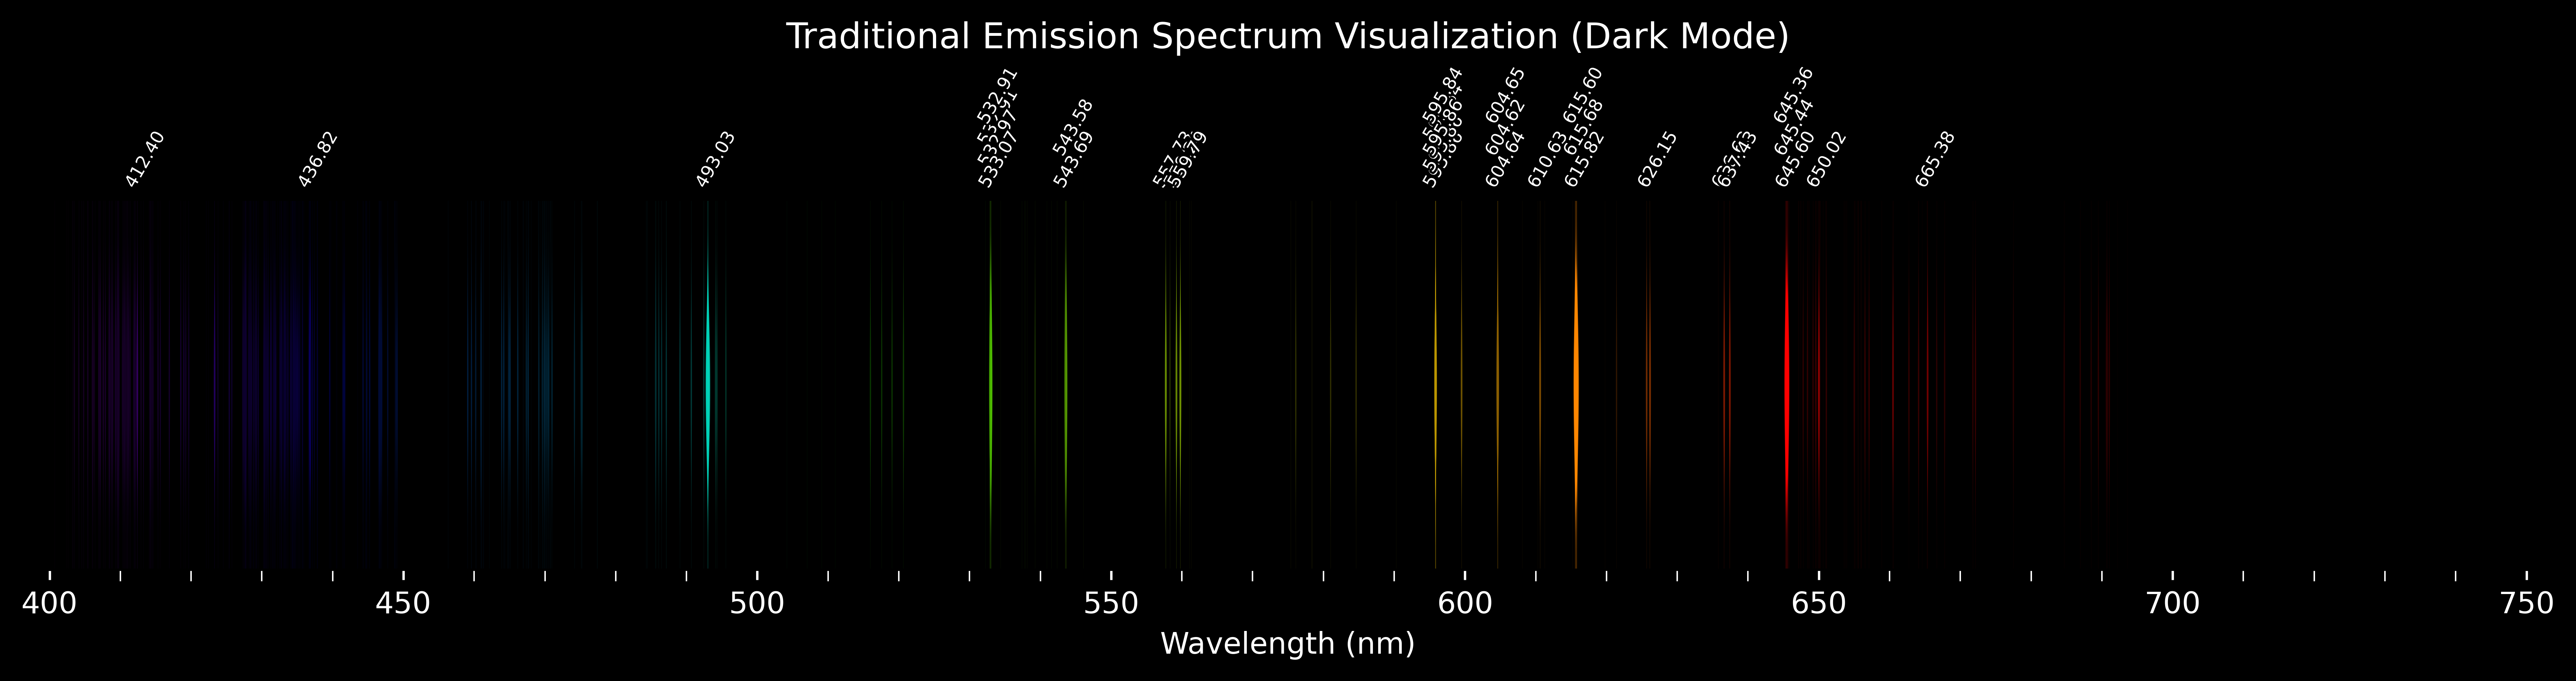

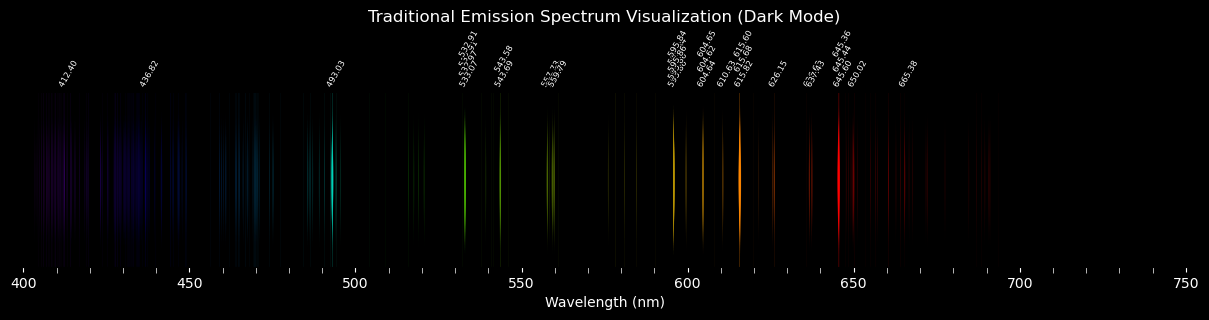

In [26]:
import io
from IPython.display import Image, display

EXCEL_FILE_PATH = 'oxygen nist 2.xlsx'
MIN_WAVELENGTH = 400.0
MAX_WAVELENGTH = 750.0
LINE_THICKNESS = 0.1

# Example: load and render without editing the source module.
df = pd.read_excel(EXCEL_FILE_PATH)

fig = plot_emission_spectrum(
    data_df=df,
    prominence_percentage=0.08,
    x_min=MIN_WAVELENGTH,
    x_max=MAX_WAVELENGTH,
    min_needle_max_width_nm=LINE_THICKNESS,
    max_needle_max_width_nm=0.3,
    glow_width_multiplier=1.3,
    glow_alpha=0.35,
    mode='dark',
    peak_label_y_position=0.77,
    max_needle_y_scale=0.75,
    )

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight', dpi=600)
from PIL import Image as PILImage
buf.seek(0)
img = PILImage.open(buf)
print("fig size (in):", fig.get_size_inches())
print("fig.dpi:", getattr(fig, "dpi", None))
print("expected pixels (w,h):", tuple(int(x * fig.dpi) for x in fig.get_size_inches()))
print("saved image pixels (w,h):", img.size)
print("saved bytes:", len(buf.getvalue()))

display(Image(data=buf.getvalue()))

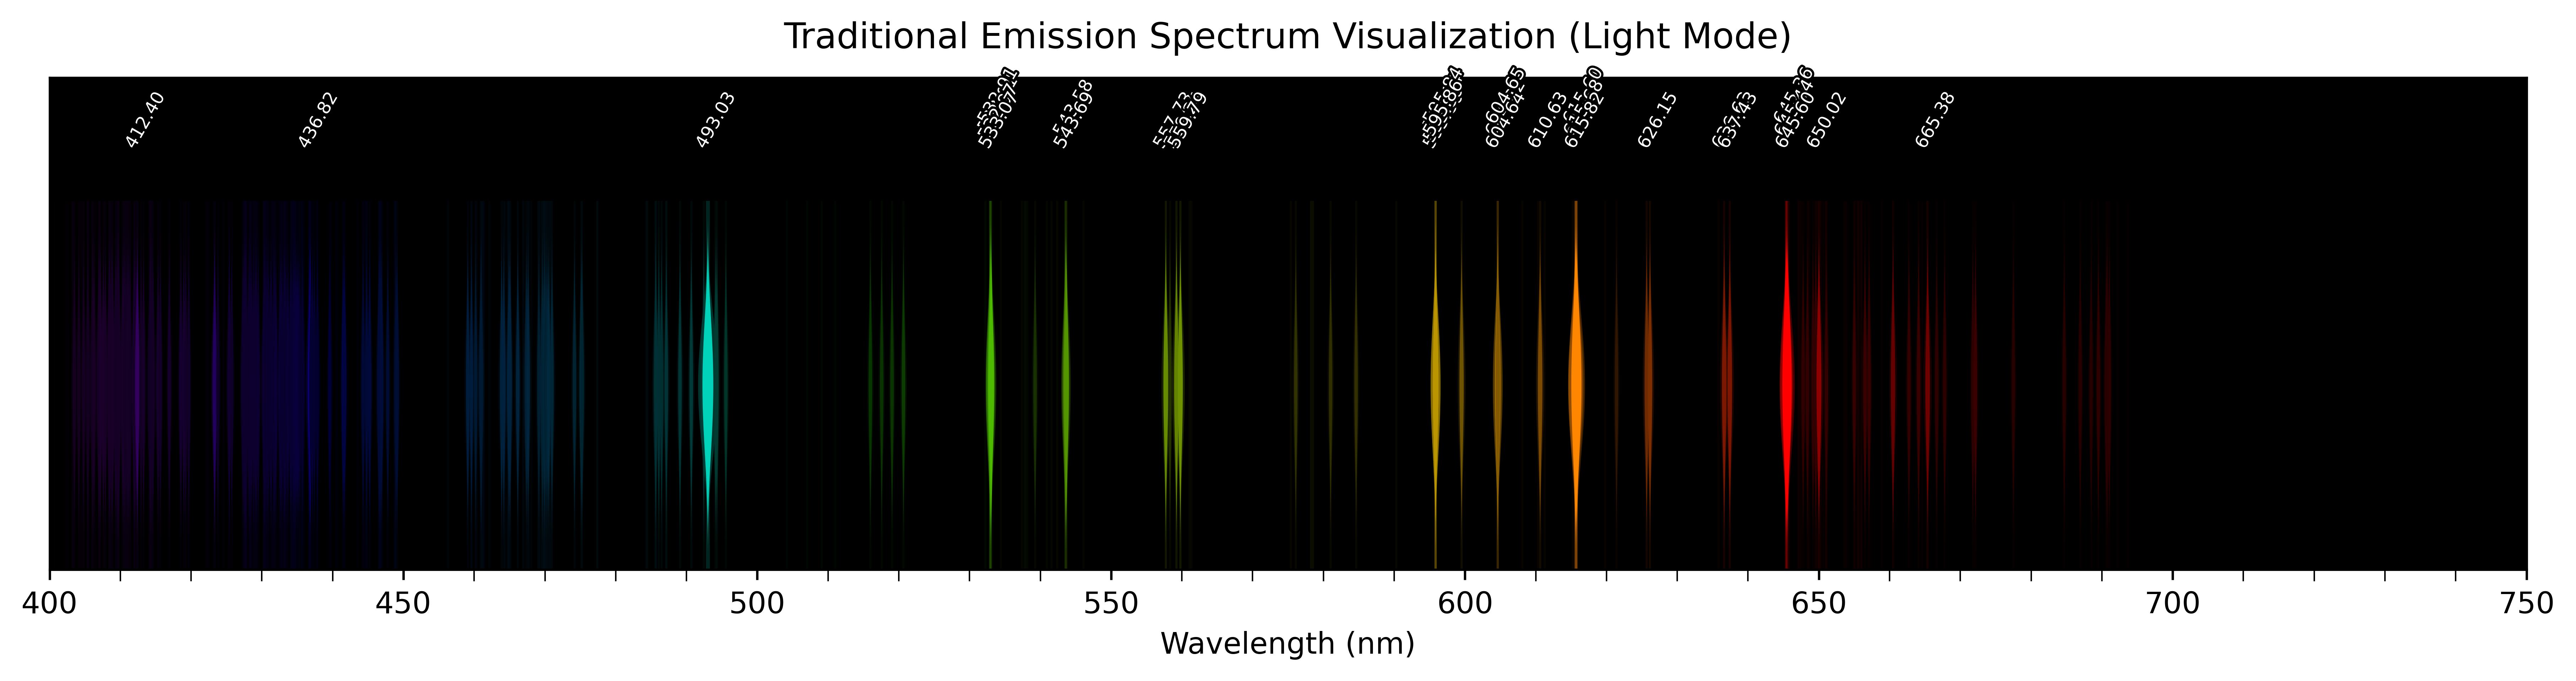

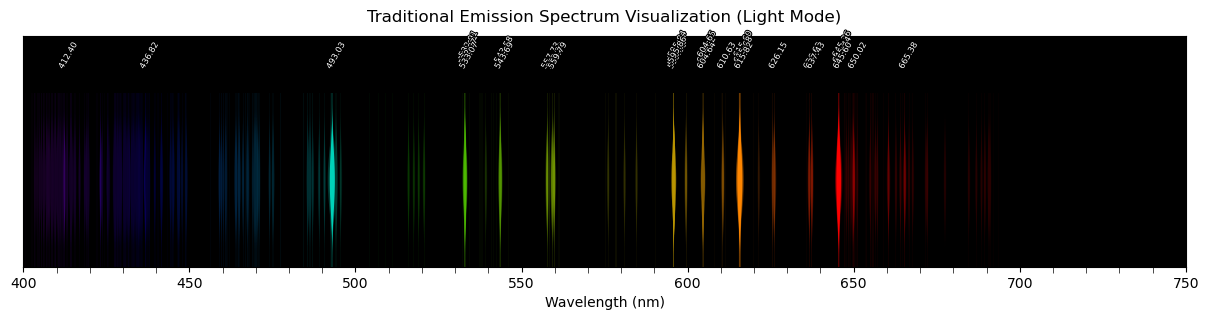

In [23]:
EXCEL_FILE_PATH = 'oxygen nist 2.xlsx'
MIN_WAVELENGTH = 400.0
MAX_WAVELENGTH = 750.0
LINE_THICKNESS = 0.3

# Example: load and render without editing the source module.
df = pd.read_excel(EXCEL_FILE_PATH)

fig = plot_emission_spectrum(
    data_df=df,
    prominence_percentage=0.08,
    x_min=MIN_WAVELENGTH,
    x_max=MAX_WAVELENGTH,
    min_needle_max_width_nm=LINE_THICKNESS,
    max_needle_max_width_nm=0.8,
    glow_width_multiplier=1.8,
    glow_alpha=0.25,
    mode='light',
    peak_label_y_position=0.85,
    max_needle_y_scale=0.75,
    )

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight', dpi=600)
buf.seek(0)
display(Image(data=buf.getvalue()))